# Why outliers detection is important?

* Treating or altering the outlier/extreme values in genuine observations is not a standard operating procedure. However, it is essential to understand their impact on your predictive models. It is left to the best judgement of the investigator to decide whether treating outliers is necessary and how to go about it.
* So, why identifying the extreme values is important? Because, it can drastically bias/change the fit estimates and predictions. Let me illustrate this using the cars dataset.
* To better understand the implications of outliers better, I am going to compare the fit of a simple linear regression model on cars dataset with and without outliers. In order to distinguish the effect clearly, I manually introduce extreme values to the original cars dataset. Then, I predict on both the datasets.

# What is an Extreme Value?
* An Extreme value is just a minimum or a maximum, it need not be much different from of the data.

# What is difference between Extreme value & Outlier?
* An Extreme value is just a minimum or a maximum, it need not be much different from the data & a point that is far a way from the other points called as outlier.
* Example:
- Age of employees<br>
Age = 21, 23, 24, 25, 26, 28, 30, 45 <br>
Where:<br>
    Extreme value =30<br>
    Outlier =45<br>

# How can we Identify an outlier?
- Using Box plots
- Using Scatter plot
- Using Z score

# Boxplot
![2.1.1.3-Outlier-Treatment-Copy-768x867.png](https://i.ibb.co/RGbfPKtd/Screenshot-2025-02-07-132758.png)
- Here we are able to visualize the data points and see the outliers that lie far away. However, Boxplots are not commonly used as it takes a lot of time to cap outliers using boxplots if there are multiple features in a dataset. Also, other methods such as standard deviation and percentiles (discussed below) are equally reliable. Also for creating boxplots generally a lot of data is required and if there is an error while capping the outliers, we have to return to the boxplot all over again. Therefore boxplots are used in applications where high precision is required such as chemical trials, risk modeling etc where it takes weeks only to prepare the data. However, in other domains such as Marketing Analysis etc, other methods can be equally reliable.

In [ ]:
# Import necessary packages
import pandas as pd
import numpy as np

In [ ]:
# Create a dataframe
df = pd.DataFrame({
    "Date": pd.date_range(start="2022-01-01",periods=100,freq="D"),
    "Item": np.random.randint(1010,1020,size=100),
    "Sales": np.random.randint(1,1000,size=100)
})

In [ ]:
# Add some outliers
df["Sales"] = df["Sales"].apply(lambda x: np.where(x>900,np.random.randint(6000,10000),x))

In [ ]:
df1=df.copy()

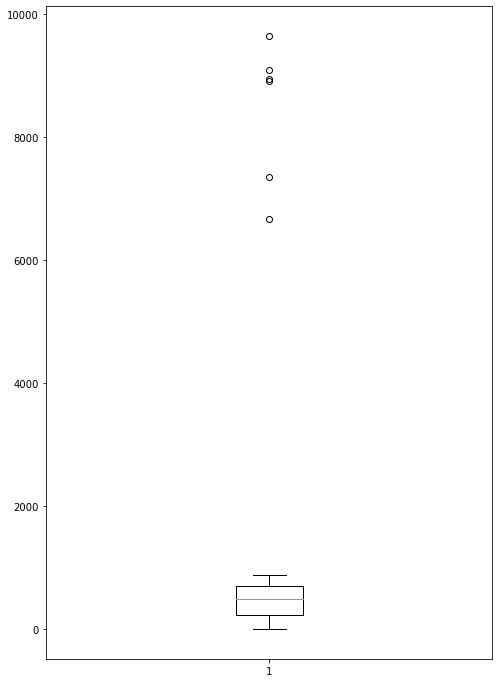

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,12))
plt.boxplot(df['Sales'])
plt.show()

# Quartile Ranges
In a dataset, extreme data points are considered to be 3 times the interquartile range which is below the first quartile or above the third quartile whereas mild outliers lie between 1.5 times the interquartile range below the first quartile or above the third quartile.<br>
![image003.jpg](https://i.ibb.co/WNq2jwYh/Screenshot-2025-02-07-160108.png)<br>
Here in the dataset, we have few mild outliers. In this dataset, any value which is above 90.875 will be capped at 90.875 while any value below 9.875 will be capped at 9.875. In this dataset, we didn’t find any extreme outliers.

In [ ]:
q1, q3 = np.nanpercentile(check_outliers(df["Sales"]), [25, 75])
iqr = q3 - q1
lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)

In [ ]:
print("Quartile 1 :",q1)
print("Quartile 3 :",q3)
print("Inter Quartile Range :", iqr)
print("Lower Fence for Extreme Outliers :",lower_bound)
print("Upper Fence for Extreme Outliers :",upper_bound)

Quartile 1 : 332.25
Quartile 3 : 798.0
Inter Quartile Range : 465.75
Lower Fence for Extreme Outliers : -366.375
Upper Fence for Extreme Outliers : 1496.625


In [ ]:
df[(df["Sales"]<lower_bound) | (df["Sales"]>upper_bound)]

,Date,Item,Sales
5,2022-01-06,1016,9743
14,2022-01-15,1017,9823
20,2022-01-21,1016,6445
25,2022-01-26,1015,6315
31,2022-02-01,1010,9785
34,2022-02-04,1013,6462
40,2022-02-10,1010,9189
44,2022-02-14,1016,8436
52,2022-02-22,1018,7807
59,2022-03-01,1011,7981


# Quantiles / Percentile
Various percentiles can be used ranging from P1 to P99 and for each variable, an arbitrary value can be taken where the percentile falls or jumps drastically. Before getting into that, it is important to be clear of the differences between quartiles, quantiles and percentiles.<br>
![image005.jpg](https://i.ibb.co/Pz6gBQys/Screenshot-2025-02-07-160211.png)<br>
Here we can see how there is a sudden increase in the value in 95 and 99 percentile so we can use the value of 95 percentile which is 52 to cap the upper extreme values while there is no major drop in the lower values indicating an absence of extreme values (outliers) in the lower end.

# Standard Deviation
![2.1.1.3-Outlier-Treatment-1024x662.png](https://i.ibb.co/rK6ySFHy/Screenshot-2025-02-07-160259.png)<br>
Another common method of capping outliers is through standard deviation. Here generally data is capped at 2 or 3 standard deviations above and below the mean. For example, if we have a variable then we can calculate the standard deviation of it and by multiplying it by 2 and subtracting this value by the mean, will get the value for the lower limit while adding this value with the mean will provide us with the upper limit. Same can be done for 3 standard deviations where we will multiply the standard deviation with 3 rather than 2.

In [ ]:
# what is a normal distribution - normal variable -

In [ ]:
mu = np.mean(df["Sales"]) # mean of the column
sigma = np.std(df["Sales"]) # standard deviation of the column

we calculate the Z-transform of the lower and upper bound using the mean and standard deviation defined above.

In [ ]:
# calculate the z-transform
z1 = ( lower_bound - mu ) / sigma
z2 = ( upper_bound - mu ) / sigma

After the Z-transform of the lower and upper bounds are calculated, we calculate the probability with SciPy's Library

In [ ]:
from scipy.stats import norm
x = np.arange(z1, z2, 0.001) # range of x in spec
x_all = np.arange(-10, 10, 0.001) # entire range of x, both in and out of spec
y = norm.pdf(x,0,1)
y2 = norm.pdf(x_all,0,1)

Finally, we build the plot

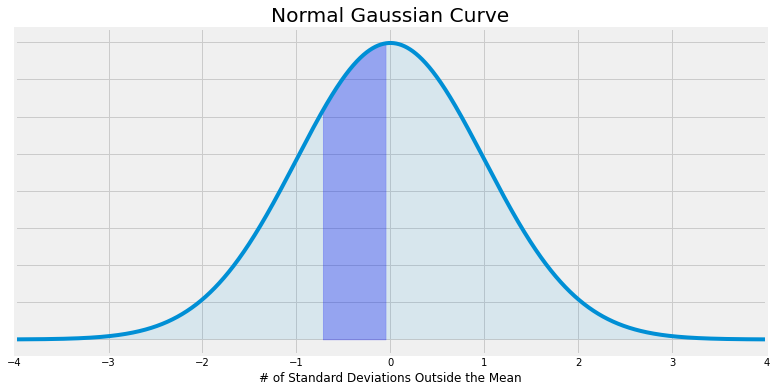

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
# build the plot
fig, ax = plt.subplots(figsize=(12,6))
plt.style.use('fivethirtyeight')
ax.plot(x_all,y2)

ax.fill_between(x,y,0, alpha=0.3, color='b')
ax.fill_between(x_all,y2,0, alpha=0.1)
ax.set_xlim([-4,4])
ax.set_xlabel('# of Standard Deviations Outside the Mean')
ax.set_yticklabels([])
ax.set_title('Normal Gaussian Curve')

plt.savefig('normal_curve.png', dpi=480, bbox_inches='tight')
plt.show()

![image009.jpg](https://i.ibb.co/TMW7G9xQ/Screenshot-2025-02-07-160325.png)<br>
Notice how when using the same dataset the results come out to be similar to percentile methods where we took 52 as the value to cap the upper value. Here also we didn’t find any lower extreme values. However, it can get difficult to decide between different values of STD and for this frequency tables can be used where the percentage of data will matter. For example, if we go with 2 std then we find 5% of outliers while with 3 std we find 1% of outliers. When dealing with outliers, discretion is required. Here 5% outliers is an acceptable amount of outliers, however, if we would have found 10% of outliers with 2 std then this could have meant that there are some natural extreme values such as in this case price of a commodity which can be expensive. In such circumstances, we can take a different std value for example 2.5 and then see how much data is being considered as an outlier. In practice, if we cap outliers using 3 std as using 2 or even 2.5 mean causes a large amount of data to become outlier indicates that the data is junk meaning that the data is of very poor quality.

# There are Two Methods for Outlier Treatment
- Interquartile Range(IQR) Method
- Z Score method

In [ ]:
df["Sales"]=df["Sales"].apply(lambda x: np.where(x > upper_bound,upper_bound,x))

In [ ]:
df["Sales"]

0      774.000
1      670.000
2      476.000
3      246.000
4      307.000
        ...   
95    1496.625
96     212.000
97     188.000
98     716.000
99     479.000
Name: Sales, Length: 100, dtype: float64

In [ ]:
from scipy import stats
z=np.abs(stats.zscore(df1["Sales"]))
print(z)

[4.86515868e+00 1.34801983e-01 4.38321678e+00 6.43907198e-02
 4.80218543e-01 4.27995737e-01 2.71327319e-01 4.68281902e-01
 1.22581847e-01 2.78041680e-01 1.45246544e-01 7.97516852e-03
 1.79564388e-01 4.24265537e-01 1.48976745e-01 3.44439247e-01
 2.88486241e-01 1.68090292e-01 2.43880504e-02 7.81029366e-02
 4.25011577e-01 4.40678419e-01 1.46738625e-01 1.05706420e-01
 8.92935379e-02 1.59421306e-01 2.00453511e-01 7.58648164e-02
 4.12634772e-02 4.01884334e-01 3.19073885e-01 2.11203948e-02
 1.24357422e-01 2.37009475e-01 1.47947210e-01 1.46895293e-02
 3.77265011e-01 3.19073885e-01 1.22865342e-01 2.43880504e-02
 3.42201127e-01 4.71266062e-01 2.78787720e-01 4.49885299e+00
 8.48172974e-02 3.89201653e-01 2.53422357e-01 2.10152032e-01
 4.24496809e-03 2.11203948e-02 4.28741777e-01 2.34771355e-01
 4.78726463e-01 1.63897547e-01 4.97377465e-01 5.45378430e+00
 8.30417220e-02 4.69773982e-01 1.24819967e-01 3.08629323e-01
 2.51930277e-01 4.12328895e-01 1.34055943e-01 3.12359524e-01
 3.95916013e-01 2.377555

We find the z-score for each of the data point in the dataset and if the z-score is greater than 3 than we can classify that point as an outlier. Any point outside of 3 standard deviations would be an outlier.

In [ ]:
threshold=3
print(np.where(z>3))

(array([ 0,  2, 43, 55], dtype=int64),)


In [ ]:
df1=df1[(z< 3)]
print(df1)

         Date  Item  Sales
1  2022-01-02  1011    494
3  2022-01-04  1010    761
4  2022-01-05  1011     31
5  2022-01-06  1019    101
6  2022-01-07  1011    311
..        ...   ...    ...
95 2022-04-06  1018    236
96 2022-04-07  1013    464
97 2022-04-08  1012    581
98 2022-04-09  1012    586
99 2022-04-10  1013     65

[96 rows x 3 columns]


# Exercise
## Creating a demo dataframe with below code
```
import pandas as pd
import numpy as np

data = {
    'Age': np.random.randint(18, 60, 100),
    'Income': np.random.randint(30000, 100000, 100),
    'Height': np.random.randint(150, 190, 100)
}
data['Age'][[5, 20, 35]] = [85, 90, 92]
data['Income'][[10, 40, 50]] = [150000, 200000, 250000]
df = pd.DataFrame(data)
```

1. Use a boxplot to visualize the "Age" and "Income" columns. Identify the data points that are outliers in each column.
**Hint:** Outliers are generally data points that lie beyond 1.5 times the interquartile range (IQR).
2. Calculate the Z-score for the "Age" and "Income" columns and identify the rows where the Z-score is greater than 3 (consider these as outliers).
**Hint:** A Z-score greater than 3 typically indicates an outlier in the dataset.
3. Write a function to cap the outliers in the "Age" and "Income" columns to the 5th and 95th percentile values.<br>
Apply this function to the dataset and display the updated dataframe.